In [128]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

In [129]:
df = pd.read_csv("LendingClub.csv")

print(f"Original data shape: {df.shape}")
df.head()

Original data shape: (395219, 23)


,loan_amnt,term,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,verification_status,loan_status,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,RENT,117000.0,Not Verified,Fully Paid,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,MORTGAGE,65000.0,Not Verified,Fully Paid,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,RENT,43057.0,Source Verified,Fully Paid,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,RENT,54000.0,Not Verified,Fully Paid,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,MORTGAGE,55000.0,Verified,Charged Off,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650"


In [130]:
# look at the non-numerical columns and their unique values.

non_numeric_cols = df.select_dtypes(exclude = ["int64", "float64"]).columns # only selects columns without ints or floats.
output = {}

for col in non_numeric_cols:
  uniques = df[col].dropna().unique()
  output[col] = uniques

for col, vals in output.items():
  print(f"Column {col} ({len(vals)} unique values):")
  print(vals)
  print("-" * 40)

# check if there are any null values in the dataframe.
print(f"Missing values:\n{df.isnull().sum()}")

Column term (2 unique values):
['36 months' '60 months']
----------------------------------------
Column grade (7 unique values):
['B' 'A' 'C' 'E' 'D' 'F' 'G']
----------------------------------------
Column sub_grade (35 unique values):
['B4' 'B5' 'B3' 'A2' 'C5' 'C3' 'A1' 'B2' 'C1' 'A5' 'E4' 'A4' 'A3' 'D1'
 'C2' 'B1' 'D3' 'D5' 'D2' 'E1' 'E2' 'E5' 'F4' 'E3' 'D4' 'G1' 'F5' 'G2'
 'C4' 'F1' 'F3' 'G5' 'G4' 'F2' 'G3']
----------------------------------------
Column home_ownership (6 unique values):
['RENT' 'MORTGAGE' 'OWN' 'OTHER' 'ANY' 'NONE']
----------------------------------------
Column verification_status (3 unique values):
['Not Verified' 'Source Verified' 'Verified']
----------------------------------------
Column loan_status (2 unique values):
['Fully Paid' 'Charged Off']
----------------------------------------
Column purpose (14 unique values):
['vacation' 'debt_consolidation' 'credit_card' 'home_improvement'
 'small_business' 'major_purchase' 'other' 'medical' 'wedding' 'car'
 '

In [131]:
# convert all categorical to numerical. extract zip codes into a feature.

# loan_status is the target variable
# df["loan_status"].value_counts() # shows 77523 defaults and 317696 repaids, 19.62% defaults.
df["loan_default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)

# extract zip codes from address
# column: address
# df["address"].astype(str).str[-6:].unique() # check if every address ends in a zipcode, [-6:] to ensure there are no random inclusions of non-zipcodes.
df["zipcode"] = df["address"].astype(str).str[-5:]
df = pd.get_dummies(df, columns = ["zipcode"], prefix = "zip", dtype = int)

# column: term
df["term_months"] = df["term"].replace({"36 months": 36, "60 months": 60}).astype(int)

# column: grade and sub_grade
grade_map = {"A": 1,"B": 2, "C": 3,"D": 4,"E": 5,"F": 6,"G": 7} # ordinal encoding to preserve order/rank in grades
sub_map = {} # ordinal encoding to preserve order/rank in sub_grades
i = 1
for g in "ABCDEFG":
  for n in range(1, 6):
    sub_map[f"{g}{n}"] = i
    i += 1
df["grade_num"] = df["grade"].map(grade_map)
df["sub_grade_num"] = df["sub_grade"].map(sub_map)

# column: home_ownership
df = pd.get_dummies(df, columns = ["home_ownership"], prefix = "own",
                    drop_first = True, dtype = int)

# column: verification_status
df = pd.get_dummies(df, columns = ["verification_status"], prefix = "verif",
                    drop_first = True, dtype = int)

# column: purpose
df = pd.get_dummies(df, columns = ["purpose"], prefix = "purpose",
                    drop_first = True, dtype = int)

# column: earliest_cr_line
today = pd.Timestamp.today()
df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], format = "%b-%Y")
df["cr_line_months"] = ((today.year - df["earliest_cr_line"].dt.year) * 12 + (today.month - df["earliest_cr_line"].dt.month))

# column: initial_list_status
df["initial_list_status"] = df["initial_list_status"].map({"w": 0, "f": 1})

# column: application_type
df = pd.get_dummies(df, columns = ["application_type"], prefix = "app",
                    drop_first = True, dtype = int)

# drop converted columns
converted_cols = ["loan_status", "address", "term", "grade", "sub_grade", "earliest_cr_line"]
df.drop(columns = converted_cols, inplace = True)

/tmp/ipython-input-3427008556.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["term_months"] = df["term"].replace({"36 months": 36, "60 months": 60}).astype(int)


In [132]:
df.tail()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,...,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,cr_line_months,app_INDIVIDUAL,app_JOINT
395214,10000.0,10.99,217.38,40000.0,15.63,6.0,0.0,1990.0,34.3,23.0,...,0,0,0,0,0,0,0,253,1,0
395215,21000.0,12.29,700.42,110000.0,21.45,6.0,0.0,43263.0,95.7,8.0,...,0,0,0,0,0,0,0,238,1,0
395216,5000.0,9.99,161.32,56500.0,17.56,15.0,0.0,32704.0,66.9,23.0,...,0,0,0,0,0,0,0,345,1,0
395217,21000.0,15.31,503.02,64000.0,15.88,9.0,0.0,15704.0,53.8,20.0,...,0,0,0,0,0,0,0,421,1,0
395218,2000.0,13.61,67.98,42996.0,8.32,3.0,0.0,4292.0,91.3,19.0,...,0,0,0,0,0,0,0,327,1,0


In [133]:
# split data into 70% training and 30% test.

# features df
X = df.drop(columns = ["loan_default"])
# target variable
Y = df["loan_default"]

# splits data, stratify keeps class proportions of ~20% defaults.
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size = 0.30, random_state = 29, stratify = Y
)

print(f"""training set size: {X_train.shape[0]} ({X_train.shape[0] / len(X) * 100}%)
training set % defaults: {Y_train.mean() * 100:.2f}%""")
print(f"""
test set size: {X_test.shape[0]} ({X_test.shape[0] / len(X) * 100}%)
test set % defaults: {Y_test.mean() * 100:.2f}%
""")
print(f"# of features: {X_train.shape[1]}")

training set size: 276653 (69.99992409271822%)
training set % defaults: 19.62%

test set size: 118566 (30.000075907281786%)
test set % defaults: 19.62%

# of features: 49


In [134]:
# feature normalization with MinMaxScaler
# scales features to [0, 1], fitting only on training set to avoid leaking.

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"training data shape after scaling: {X_train_scaled.shape}")
print(f"test data shape after scaling: {X_test_scaled.shape}")

training data shape after scaling: (276653, 49)
test data shape after scaling: (118566, 49)


In [135]:
model = Sequential([
    Input(shape = (X_train_scaled.shape[1], )),
    Dense(128, activation = "relu", name = "input_layer_0"),
    Dropout(0.3, name = "dropout_1"),
    Dense(64, activation = "relu", name = "hidden_layer_1"),
    Dropout(0.3, name = "dropout_2"),
    Dense(32, activation = "relu", name = "hidden_layer_2"),
    Dropout(0.2, name ="dropout_3"),
    # sigmoid for binary classification.
    Dense(1, activation = "sigmoid", name = "output_layer_0")
])

model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy", tf.keras.metrics.AUC(name = "auc")]
)

model.summary()

# stop training when val_loss hasn't improved/decreased after 10 epochs.
early_stopping = EarlyStopping(
    monitor = "val_loss",
    mode = "min",
    patience = 10,
    restore_best_weights = True,
    verbose = 1
)

history = model.fit(
    X_train_scaled, Y_train,
    validation_split = 0.2,
    epochs = 100,
    batch_size = 32,
    callbacks = [early_stopping],
    verbose = 1
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_0 (Dense)           │ (None, 128)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer_0 (Dense)          │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,769 (65.50 KB)

 Trainable params: 16,769 (65.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
6917/6917 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.8781 - auc: 0.8700 - loss: 0.2940 - val_accuracy: 0.8875 - val_auc: 0.8978 - val_loss: 0.2671
Epoch 2/100
6917/6917 ━━━━━━━━━━━━━━━━━━━━ 40s 4ms/step - accuracy: 0.8869 - auc: 0.8991 - loss: 0.2639 - val_accuracy: 0.8875 - val_auc: 0.8981 - val_loss: 0.2646
Epoch 3/100
6917/6917 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.8865 - auc: 0.8999 - loss: 0.2632 - val_accuracy: 0.8875 - val_auc: 0.8977 - val_loss: 0.2636
Epoch 4/100
6917/6917 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.8875 - auc: 0.9019 - loss: 0.2609 - val_accuracy: 0.8874 - val_auc: 0.8988 - val_loss: 0.2628
Epoch 5/100
6917/6917 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.8879 - auc: 0.9028 - loss: 0.2600 - val_accuracy: 0.8875 - val_auc: 0.8986 - val_loss: 0.2632
Epoch 6/100
6917/6917 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.8877 - auc: 0.9017 - loss: 0.2605 - val_accuracy: 0.8875 - val_auc: 0.8984 - val_loss: 0.2639
Epoch 7/100
6917

In [136]:
# flattens predicted probabilities to 1D for training and test sets
Y_train_pred_prob = model.predict(X_train_scaled).flatten()
Y_test_pred_prob = model.predict(X_test_scaled).flatten()

"""
first tested threshold = 0.5 as a default.
  we move away from this because the model is conservatively predicting defaults.
  even though this results in high precision, it misses a lot of true defaults (low recall).
  this is due to the 80/20 imbalance with majority repaid loans, making the model biased towards predicting repaid loans.

  we lower the threshold to let the model predict more defaults and improve recall.
  this is tuned using the ROC and PR/F1 curves instead of relying on the default 0.5.


second threshold = ~0.2 found via ROC curve. (note that this changes per model training).
  this came from maximizing Youden’s J statistic (J = TPR − FPR) on the ROC curve.
  this threshold is the point where the model finds the best balance between sensitivity (recall) and false positive rate.
  because it lowers the threshold drastically, the model becomes far more aggressive in predicting defaults.
  this greatly boosts recall but also increases the number of repaid loans that get flagged as defaults (false positives).

  it does seem to maximize overall separation between the classes.
  it appears too aggressive for lending decisions because it produces a large number of false positives.


third threshold = ~0.3 found via PR curve / F1-score. (note that this changes per model training).
  this came from maximizing the F1 score on the precision–recall curve.
  this threshold is the point where the model finds the best balance between precision and recall for the default class instead of focusing heavily on one or the other.
  compared to the 0.178 ROC threshold, this value is less aggressive.
  it produces fewer false positives while still catching more defaults than the 0.5 baseline.

  at this threshold, recall substantially improves and precision stays reasonably high.
  the model identifies a larger share of true defaults while lowering the number of false alarms.
  this seems to be a goldilocks zone for the model, between a conservative 0.5 or the aggressive 0.178.


overall, the choice of threshold is dependent on the business case.
different lenders can have different problems and desired trade-off between precision and recall.
this can be due to risk tolerance, financial costs, etc.

for example:
if missing a default is very expensive, a lower threshold (higher recall) makes sense.
if false positives create too much lost revenue, a higher threshold (higher precision) may be desired.

the model provides the curves and metrics, but the “best” threshold is ultimately defined by the user and their valued trade-offs.
"""

# find optimal thresholds using ROC and PR/F1 after first eval.
Y_train_pred = (Y_train_pred_prob > 0.318).astype(int)
Y_test_pred = (Y_test_pred_prob > 0.318).astype(int)

# training set performance
train_loss, train_acc, train_auc = model.evaluate(X_train_scaled, Y_train, verbose = 0)
print(f"""\nTRAINING SET PERFORMANCE:
  Loss: {train_loss:.4f}
  Accuracy: {train_acc:.4f}
  AUC-ROC: {train_auc:.4f}
      """)

# test set performance
test_loss, test_acc, test_auc = model.evaluate(X_test_scaled, Y_test, verbose = 0)
print(f"""TEST SET PERFORMANCE:
  Loss: {test_loss:.4f}
  Accuracy: {test_acc:.4f}
  AUC-ROC: {test_auc:.4f}
      """)

# classification report
print("CLASSIFICATION REPORT (Test Set):")
print(classification_report(Y_test, Y_test_pred, target_names = ["Repaid", "Default"]))

# confusion matrix
print("CONFUSION MATRIX (Test Set):")
print(confusion_matrix(Y_test, Y_test_pred))

8646/8646 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
3706/3706 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step

TRAINING SET PERFORMANCE:
  Loss: 0.2558
  Accuracy: 0.8890
  AUC-ROC: 0.9069
      
TEST SET PERFORMANCE:
  Loss: 0.2574
  Accuracy: 0.8886
  AUC-ROC: 0.9058
      
CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

      Repaid       0.91      0.92      0.92     95309
     Default       0.67      0.64      0.65     23257

    accuracy                           0.87    118566
   macro avg       0.79      0.78      0.79    118566
weighted avg       0.87      0.87      0.87    118566

CONFUSION MATRIX (Test Set):
[[88039  7270]
 [ 8391 14866]]


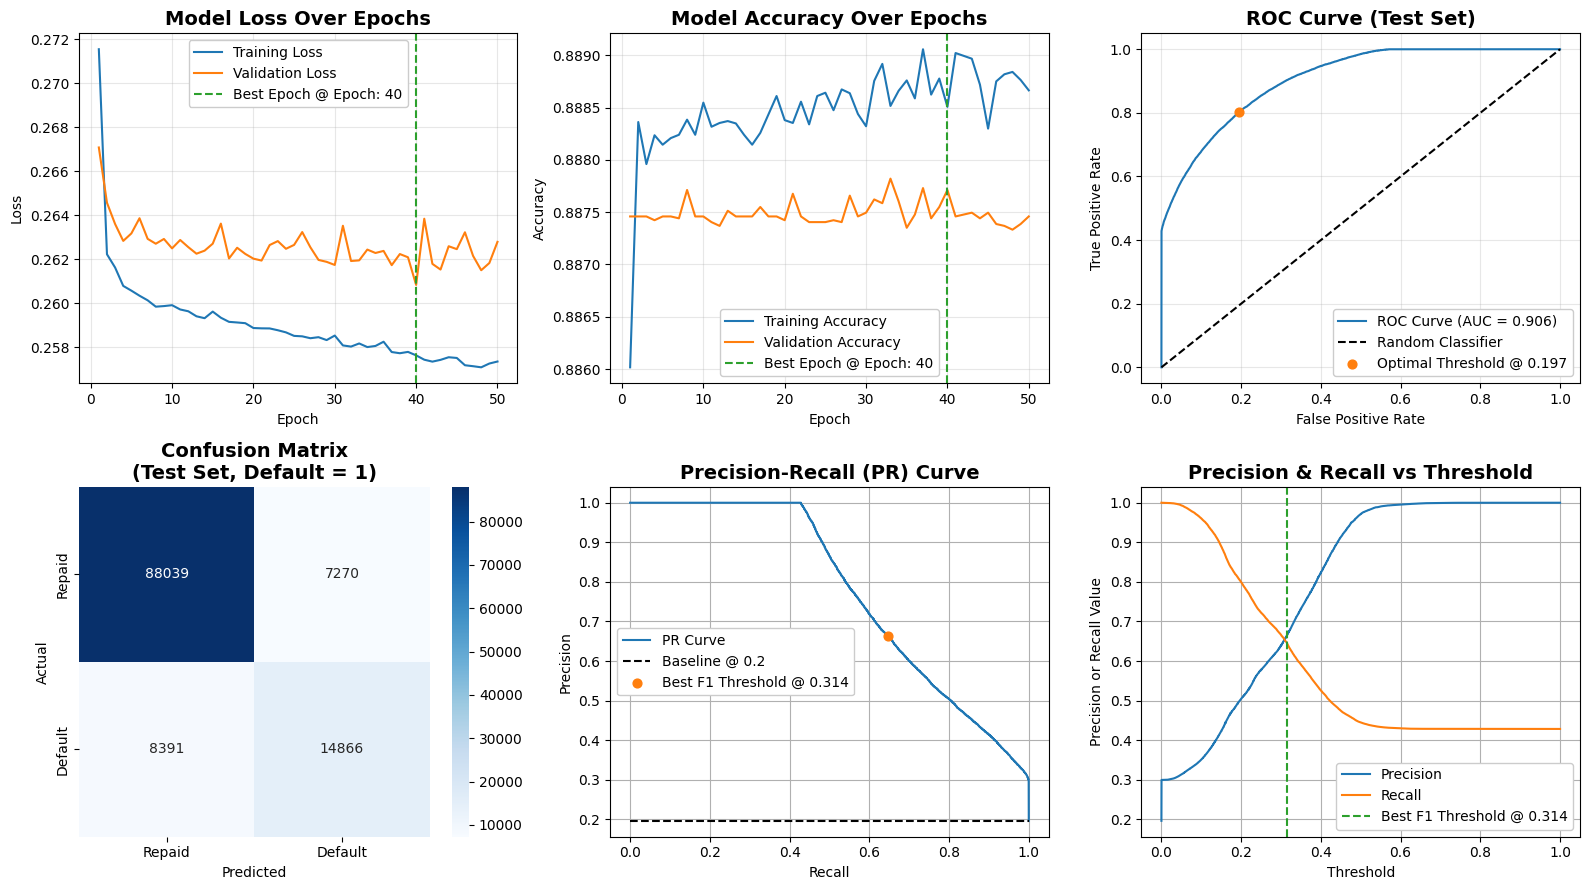

In [137]:
fig, axes = plt.subplots(2, 3, figsize = (16, 9))

# note best epoch for plotting
epochs = range(1, len(history.history["loss"]) + 1) # adjust x-axis for plot readability
val_loss = history.history["val_loss"]
val_accuracy = history.history["val_accuracy"]
best_epoch = val_loss.index(min(val_loss)) + 1

# 1: training history - loss
axes[0, 0].plot(epochs, history.history["loss"], label = "Training Loss")
axes[0, 0].plot(epochs, val_loss, label = "Validation Loss")
axes[0, 0].axvline(best_epoch, color = "#2ca02c", linestyle = "--",
                  label = f"Best Epoch @ Epoch: {best_epoch}")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Model Loss Over Epochs", fontsize = 14, fontweight = "bold")
axes[0, 0].legend(framealpha = 1)
axes[0, 0].grid(True, alpha = 0.3)

# 2: training history - accuracy
axes[0, 1].plot(epochs, history.history["accuracy"], label = "Training Accuracy")
axes[0, 1].plot(epochs, val_accuracy, label = "Validation Accuracy")
axes[0, 1].axvline(best_epoch, color = "#2ca02c", linestyle = "--",
                  label = f"Best Epoch @ Epoch: {best_epoch}")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].set_title("Model Accuracy Over Epochs", fontsize = 14, fontweight = "bold")
axes[0, 1].legend(framealpha = 1)
axes[0, 1].grid(True, alpha = 0.3)

# 3: ROC curve
fpr, tpr, thresholds = roc_curve(Y_test, Y_test_pred_prob)
# calculate optimal ROC threshold via Youden's J, maximizes class separation.
J = tpr - fpr
optimal_idx = np.argmax(J)
optimal_threshold = thresholds[optimal_idx]
# plot
axes[0, 2].plot(fpr, tpr, label = f"ROC Curve (AUC = {test_auc:.3f})")
axes[0, 2].plot([0, 1], [0, 1], "k--", label = "Random Classifier")
axes[0, 2].scatter(fpr[optimal_idx], tpr[optimal_idx],
                   color = "#ff7f0e", s = 40, zorder = 3,
                   label = f"Optimal Threshold @ {optimal_threshold:.3f}")
axes[0, 2].set_xlabel("False Positive Rate")
axes[0, 2].set_ylabel("True Positive Rate")
axes[0, 2].set_title("ROC Curve (Test Set)",
                     fontsize = 14, fontweight = "bold")
axes[0, 2].legend(loc = "lower right", framealpha = 1)
axes[0, 2].grid(True, alpha = 0.3)

# 4: confusion matrix heatmap
sns.heatmap(confusion_matrix(Y_test, Y_test_pred), annot = True, fmt = "d",
            ax = axes[1, 0], cmap = "Blues",
            xticklabels = ["Repaid", "Default"],
            yticklabels = ["Repaid", "Default"])
axes[1, 0].set_ylabel("Actual")
axes[1, 0].set_xlabel("Predicted")
axes[1, 0].set_title("Confusion Matrix\n(Test Set, Default = 1)",
                     fontsize = 14, fontweight = "bold")

# 5: precision-recall (pr) curve with baseline
precision, recall, thresholds = precision_recall_curve(Y_test, Y_test_pred_prob)
axes[1,1].plot(recall, precision, label = "PR Curve")
baseline = Y_test.mean()  # baseline = 20% defaults in data
axes[1,1].hlines(baseline, xmin = 0, xmax = 1, color = "#000000",
                 linestyle = "--", label = "Baseline @ 0.2")
# calculate optimal pr/f1 threshold, maximizing precision/recall harmonic mean.
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])
optimal_idx = f1_scores.argmax()
best_threshold = thresholds[optimal_idx]
# plot
axes[1,1].scatter(recall[optimal_idx], precision[optimal_idx],
                  color = "#ff7f0e", s = 40, zorder = 3,
                  label = f"Best F1 Threshold @ {best_threshold:.3f}")
axes[1,1].set_title("Precision-Recall (PR) Curve",
                    fontsize = 14, fontweight = "bold")
axes[1,1].set_xlabel("Recall")
axes[1,1].set_ylabel("Precision")
axes[1,1].legend(loc = "center left", framealpha = 1)
axes[1,1].grid(True)

# 6: precision & recall vs threshold
axes[1,2].plot(thresholds, precision[:-1], label = "Precision")
axes[1,2].plot(thresholds, recall[:-1], label = "Recall")
axes[1,2].axvline(best_threshold, color = "#2ca02c", linestyle = "--",
                  label = f"Best F1 Threshold @ {best_threshold:.3f}")
axes[1,2].set_title("Precision & Recall vs Threshold",
                    fontsize = 14, fontweight = "bold")
axes[1,2].set_xlabel("Threshold")
axes[1,2].set_ylabel("Precision or Recall Value")
axes[1,2].legend(framealpha = 1)
axes[1,2].grid(True)

plt.tight_layout()
plt.show()